# Exploratory Data Analysis

##### Before moving to the models, we perform Exploratory Data Analysis (EDA) to understand the distribution of our target variable and the relationships between features.

### Data Dictionary
Below is the description of the features present in the Heart Disease dataset:

| Variable | Description |
| :--- | :--- |
| **age** | Age of the patient in years. |
| **sex** | Gender (1 = Male, 0 = Female). |
| **cp** | Chest pain type (4 types). |
| **trestbps** | Resting blood pressure (in mm Hg on admission). |
| **chol** | Serum cholestoral in mg/dl. |
| **fbs** | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false). |
| **restecg** | Resting electrocardiographic results. |
| **thalach** | Maximum heart rate achieved. |
| **exang** | Exercise induced angina (1 = yes, 0 = no). |
| **oldpeak** | ST depression induced by exercise relative to rest. |
| **slope** | The slope of the peak exercise ST segment. |
| **ca** | Number of major vessels (0-3) colored by flourosopy. |
| **thal** | Thalassemia (a blood disorder). |
| **target** | Diagnosis (1 = Heart Disease, 0 = No Heart Disease). |

In [121]:
# importing the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [122]:
# importing the data from google drive
heart_df = pd.read_csv('/content/drive/MyDrive/ML datasets/heart_disease.csv')

In [123]:
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [124]:
heart_df.shape

(1025, 14)

In [125]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [126]:
heart_df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


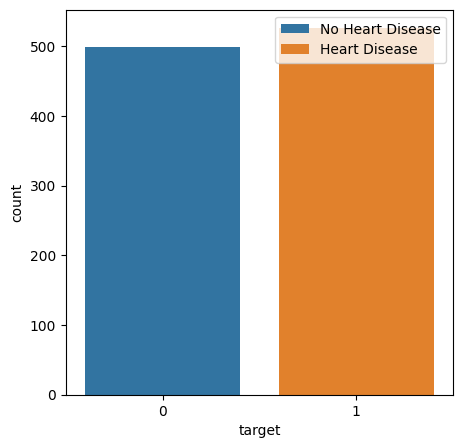

In [127]:
# distribution of the target Variable
plt.figure(figsize = (5, 5))
sns.countplot(x = 'target', data = heart_df, hue = 'target')
plt.legend(['No Heart Disease', 'Heart Disease'])
plt.show()

### Distribution of the Features

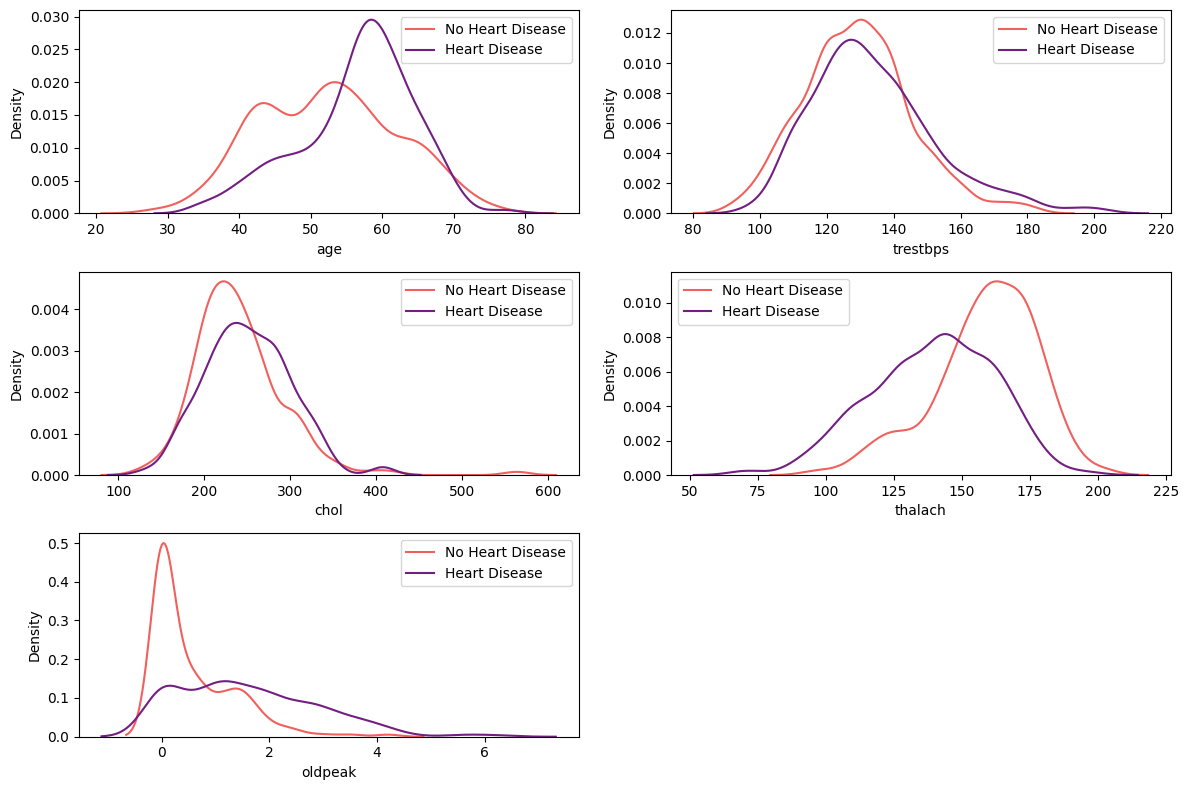

In [128]:
# histograms of numerical variables
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize = (12, 8))
for i, feature_name in enumerate(numerical_features):
  ax = plt.subplot(3, 2, i+1)
  sns.kdeplot(x = feature_name, data = heart_df, hue = 'target', palette = 'magma')
  plt.legend(['No Heart Disease', 'Heart Disease'])
plt.tight_layout()
plt.show()

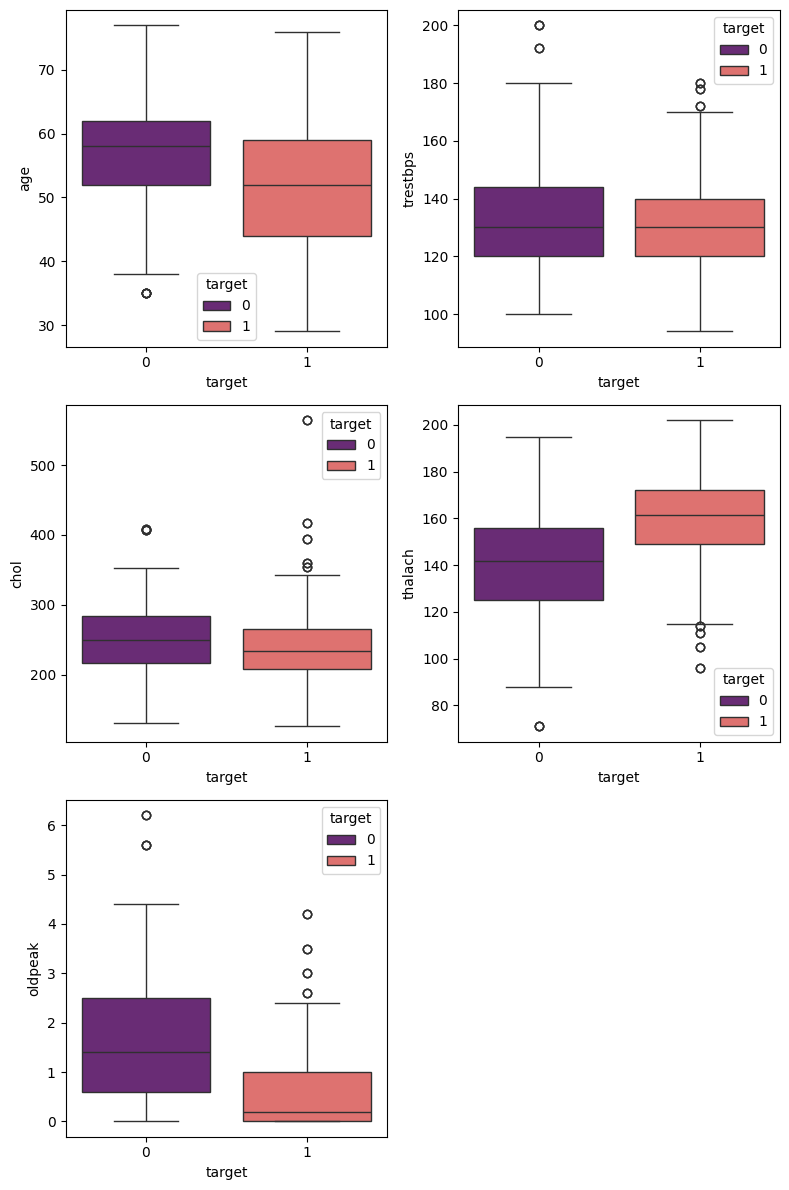

In [129]:
# boxplots for numerical features with respect to target variable
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize = (8, 12))
for i, feature_name in enumerate(numerical_features):
  plt.subplot(3, 2, i+1)
  sns.boxplot(x = 'target', y = feature_name, data = heart_df, hue = 'target', palette = 'magma')
plt.tight_layout()
plt.show()

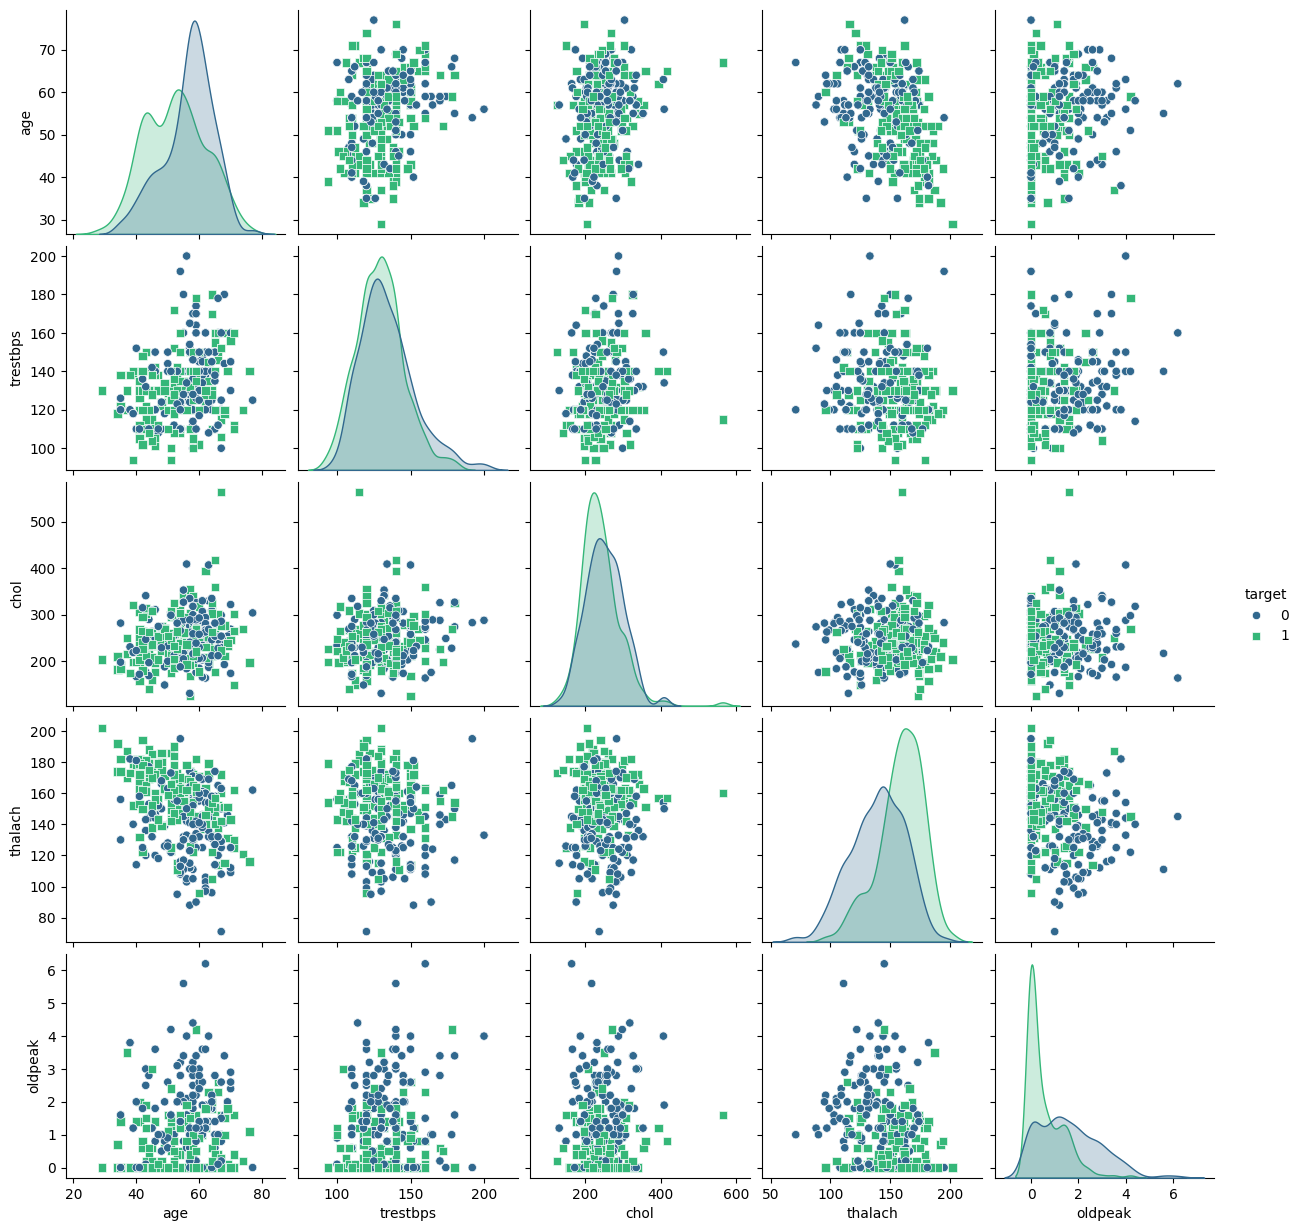

In [130]:
# pairplot
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']
sns.pairplot(heart_df[features], hue='target', palette='viridis', markers=["o", "s"])
plt.show()

In [131]:
# correlation matrix
heart_corr = heart_df[numerical_features].corr()
print(heart_corr)

               age  trestbps      chol   thalach   oldpeak
age       1.000000  0.271121  0.219823 -0.390227  0.208137
trestbps  0.271121  1.000000  0.127977 -0.039264  0.187434
chol      0.219823  0.127977  1.000000 -0.021772  0.064880
thalach  -0.390227 -0.039264 -0.021772  1.000000 -0.349796
oldpeak   0.208137  0.187434  0.064880 -0.349796  1.000000


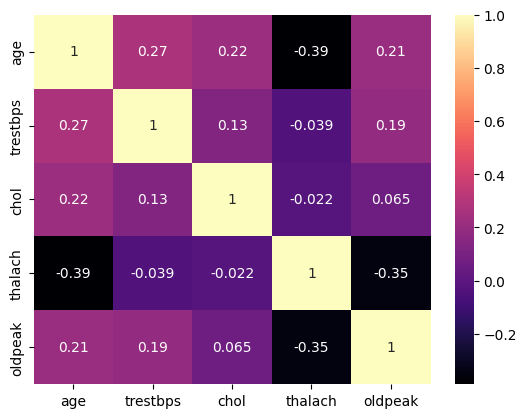

In [132]:
# heatmap
sns.heatmap(heart_corr, annot = True, cmap = 'magma')
plt.show()